### **Praktikum 7.1: Computer Vision - Object Detection dengan YOLO**

COMPUTER VISION: OBJECT DETECTION WITH YOLO
Mengunduh ../config/yolov3.cfg... Mohon tunggu (YOLOv3 Weights lumayan besar)...
../config/yolov3.cfg berhasil diunduh.
Mengunduh ../config/yolov3.weights... Mohon tunggu (YOLOv3 Weights lumayan besar)...
../config/yolov3.weights berhasil diunduh.
Mengunduh ../config/coco.names... Mohon tunggu (YOLOv3 Weights lumayan besar)...
../config/coco.names berhasil diunduh.
Mengunduh gambar sampel dari: https://raw.githubusercontent.com/pjreddie/darknet/master/data/dog.jpg


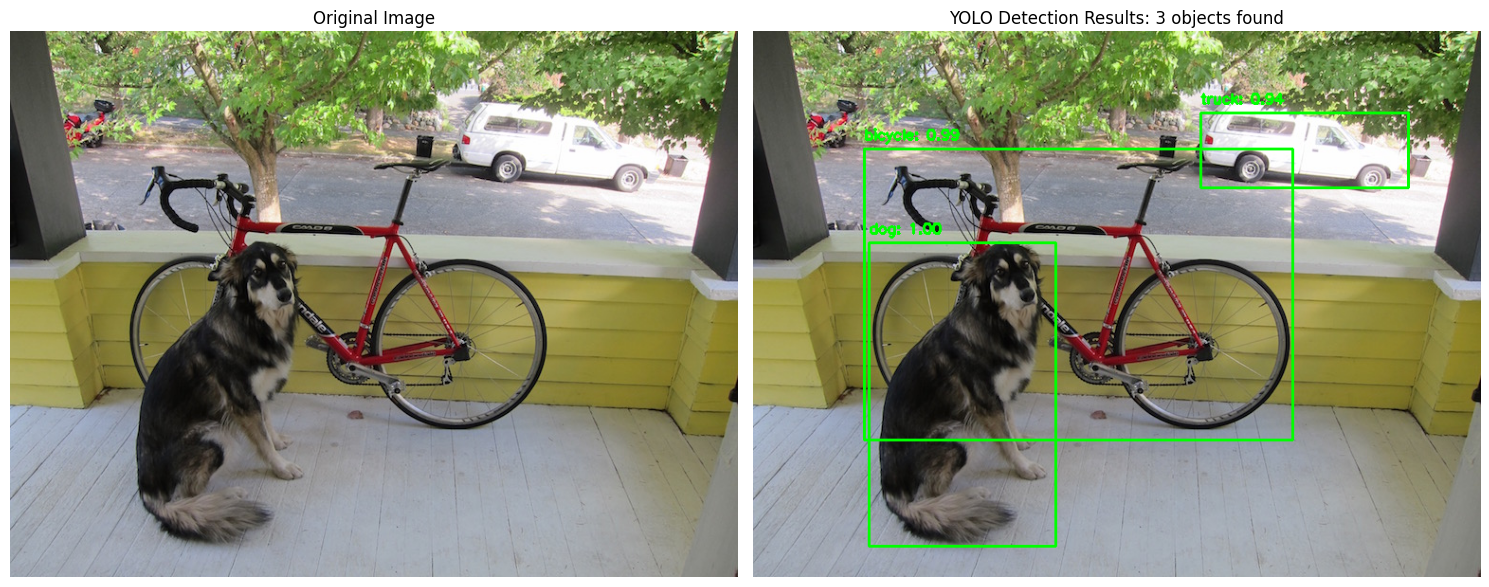

Detected 3 objects in the image


In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO
import os
from PIL import Image

def praktikum_7_1():
    print("COMPUTER VISION: OBJECT DETECTION WITH YOLO")
    print("=" * 50)

    # 1. Download sample image (Diberi URL sampel gambar standar COCO)
    def download_sample_image():
        url = "https://raw.githubusercontent.com/pjreddie/darknet/master/data/dog.jpg"
        print(f"Mengunduh gambar sampel dari: {url}")
        response = requests.get(url)
        img = Image.open(BytesIO(response.content))
        return cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)

    # Helper untuk mengunduh file besar secara lokal
    def download_file_locally(url, filename):
        if not os.path.exists(filename):
            print(f"Mengunduh {filename}... Mohon tunggu (YOLOv3 Weights lumayan besar)...")
            response = requests.get(url, stream=True)
            with open(filename, 'wb') as f:
                for chunk in response.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)
            print(f"{filename} berhasil diunduh.")
        else:
            print(f"{filename} sudah ada di direktori lokal.")

    # 2. Load YOLO model dengan mengunduh file-nya terlebih dahulu
    def load_yolo_model():
        # URL konfigurasi resmi dari repository Darknet
        config_url = "https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg"
        weights_url = "https://pjreddie.com/media/files/yolov3.weights"
        names_url = "https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names"

        # Tentukan nama file penyimpanan lokal
        config_file = "../config/yolov3.cfg"
        weights_file = "../config/yolov3.weights"
        names_file = "../config/coco.names"

        # Unduh file jika belum ada di lokal komputer
        download_file_locally(config_url, config_file)
        download_file_locally(weights_url, weights_file)
        download_file_locally(names_url, names_file)

        # Muat daftar kelas (class names) dari file lokal
        with open(names_file, 'r') as f:
            classes = f.read().strip().split('\n')

        # Inisialisasi jaringan saraf menggunakan path file lokal yang sudah diunduh
        net = cv2.dnn.readNetFromDarknet(config_file, weights_file)
        net.setPreferableBackend(cv2.dnn.DNN_BACKEND_OPENCV)
        net.setPreferableTarget(cv2.dnn.DNN_TARGET_CPU)

        return net, classes

    # Object detection function (Tetap sama seperti logika Anda)
    def detect_objects_yolo(net, image, classes, conf_threshold=0.5, nms_threshold=0.4):
        height, width = image.shape[:2]

        blob = cv2.dnn.blobFromImage(image, 1 / 255.0, (416, 416), swapRB=True, crop=False)
        net.setInput(blob)

        layer_names = net.getLayerNames()
        output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]

        outputs = net.forward(output_layers)

        boxes = []
        confidences = []
        class_ids = []

        for output in outputs:
            for detection in output:
                scores = detection[5:]
                class_id = np.argmax(scores)
                confidence = scores[class_id]

                if confidence > conf_threshold:
                    center_x = int(detection[0] * width)
                    center_y = int(detection[1] * height)
                    w = int(detection[2] * width)
                    h = int(detection[3] * height)

                    x = int(center_x - w / 2)
                    y = int(center_y - h / 2)

                    boxes.append([x, y, w, h])
                    confidences.append(float(confidence))
                    class_ids.append(class_id)

        indices = cv2.dnn.NMSBoxes(boxes, confidences, conf_threshold, nms_threshold)

        result_image = image.copy()
        if len(indices) > 0:
            for i in indices.flatten():
                x, y, w, h = boxes[i]
                label = f"{classes[class_ids[i]]}: {confidences[i]:.2f}"

                cv2.rectangle(result_image, (x, y), (x + w, y + h), (0, 255, 0), 2)
                cv2.putText(result_image, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        return result_image, len(indices)

    try:
        # Menjalankan pipeline deteksi objek
        net, classes = load_yolo_model()
        image = download_sample_image()

        result_image, num_detections = detect_objects_yolo(net, image, classes)

        # Menampilkan output visualisasi
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        ax1.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        ax1.set_title('Original Image')
        ax1.axis('off')

        ax2.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
        ax2.set_title(f'YOLO Detection Results: {num_detections} objects found')
        ax2.axis('off')

        plt.tight_layout()
        plt.show()

        print(f"Detected {num_detections} objects in the image")
        return result_image, num_detections

    except Exception as e:
        print(f"YOLO demonstration skipped: {e}")
        print("Using simulated object detection...")
        return simulate_object_detection()

# Jalankan fungsi utama
result_image, detections = praktikum_7_1()